## Zero-Shot Reference Mapping chord blood (cb) dataset

In [3]:
!pip install -U scgpt "torch<=2.2.2" "numpy<2" "umap-learn<0.5.7" torchtext

Defaulting to user installation because normal site-packages is not writeable
  Using cached torchtext-0.18.0-cp310-cp310-manylinux1_x86_64.whl.metadata (7.9 kB)
INFO: pip is looking at multiple versions of torchtext to determine which version is compatible with other requirements. This could take a while.
  Using cached torchtext-0.17.2-cp310-cp310-manylinux1_x86_64.whl.metadata (7.9 kB)
Using cached torchtext-0.17.2-cp310-cp310-manylinux1_x86_64.whl (2.0 MB)


In [1]:
from pathlib import Path
import numpy as np
from scipy.stats import mode
import scanpy as sc
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import sys
import scgpt as scg
import os
#sys.path.insert(0, "../")
# sys.path.insert(0, "../../")

# extra dependency for similarity search
try:
    import faiss

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

/opt/conda/envs/scgpt/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/envs/scgpt/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/envs/scgpt/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/envs/scgpt/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/envs/scgpt/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.rea

faiss not installed! We highly recommend installing it for fast similarity search.
To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss


To check the directory (and to modify use %cd and other linux comands) both works

In [7]:
# %pwd
# os.getcwd()

'/home/revalescente/repos/scFound_bench/py_scripts/zero_shot_annotation'

### Read the dataset

In [4]:
model_dir = Path("/home/revalescente/repos/scGPT/scGPT/save/scGPT_human")
train_be1 = sc.read_h5ad('/home/revalescente/datasets/anndata/train_BE1_sce.h5ad')
test_be1 = sc.read_h5ad('/home/revalescente/datasets/anndata/test_BE1_sce.h5ad')

cell_type_key = "Sample"
gene_col = "gene_names" # name of the vector in the anndata.var with the gene names 

In [3]:
train_be1

AnnData object with n_obs × n_vars = 20397 × 36753
    obs: 'Sample', 'Barcode', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'discard', 'is_train'
    var: 'ID', 'Symbol', 'Type', 'gene_names'
    uns: 'Samples'
    layers: 'counts'

In [5]:
train_be1.X = train_be1.layers['counts']
test_be1.X = test_be1.layers['counts']


sc.pp.normalize_total(train_be1, target_sum=1e4)
sc.pp.log1p(train_be1)
sc.pp.normalize_total(test_be1, target_sum=1e4)
sc.pp.log1p(test_be1)

Embed the train and test dataset

In [6]:
ref_embed_adata = scg.tasks.embed_data(
    train_be1,
    model_dir,
    gene_col=gene_col,
    batch_size=64
)

test_embed_adata = scg.tasks.embed_data(
    test_be1,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

scGPT - INFO - match 24288/36753 genes in vocabulary of size 60697.


/home/revalescente/.local/lib/python3.10/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|███████████████████████████████████████████████████████████████████████████████████| 319/319 [00:36<00:00,  8.68it/s]
/home/revalescente/.local/lib/python3.10/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


scGPT - INFO - match 24288/36753 genes in vocabulary of size 60697.


/home/revalescente/.local/lib/python3.10/site-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|███████████████████████████████████████████████████████████████████████████████████| 137/137 [00:16<00:00,  8.17it/s]
/home/revalescente/.local/lib/python3.10/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [29]:
ref_embed_adata

AnnData object with n_obs × n_vars = 5476 × 17769
    obs: 'adt.discard', 'mito.discard', 'discard', 'species', 'celltype', 'markers', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'altexps_scADT_sum', 'altexps_scADT_detected', 'altexps_scADT_percent', 'total', 'is_train'
    var: 'gene_names', 'id_in_vocab'
    obsm: 'X_scGPT'
    layers: 'counts'

In [7]:
# concatenate the two datasets
adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
# mark the reference vs. query dataset
adata_concat.obs["is_ref"] = ["Query"] * len(test_embed_adata) + ["Reference"] * len(
    ref_embed_adata
)
adata_concat.obs["is_ref"] = adata_concat.obs["is_ref"].astype("category")
# mask the query dataset cell types
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].astype("category")
adata_concat.obs[cell_type_key] = adata_concat.obs[cell_type_key].cat.add_categories(["To be predicted"])
adata_concat.obs[cell_type_key][: len(test_embed_adata)] = "To be predicted"

/tmp/ipykernel_376532/4201321170.py:2: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")


# Visualize the embeddings

/opt/conda/envs/scgpt/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/scgpt/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


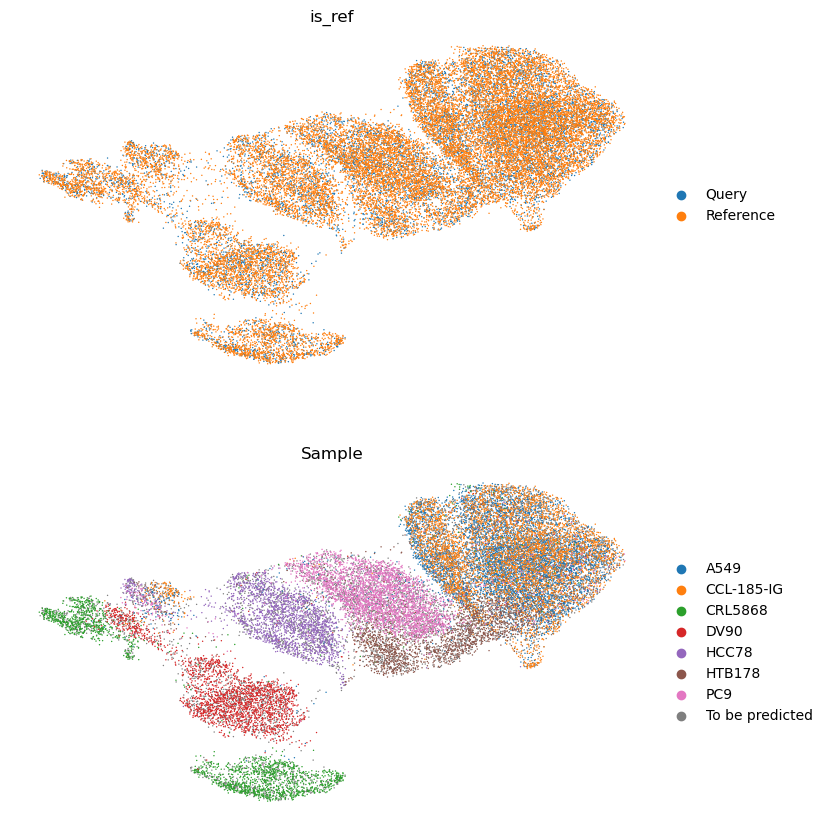

In [8]:
sc.pp.neighbors(adata_concat, use_rep="X_scGPT")
sc.tl.umap(adata_concat)
sc.pl.umap(
    adata_concat, color=["is_ref", cell_type_key], wspace=0.4, frameon=False, ncols=1
)

# Reference mapping and transfer the annotation

Function to use when faiss is not installed

In [9]:
# Those functions are only used when faiss is not installed
def l2_sim(a, b):
    sims = -np.linalg.norm(a - b, axis=1)
    return sims

def get_similar_vectors(vector, ref, top_k=10):
        # sims = cos_sim(vector, ref)
        sims = l2_sim(vector, ref)
        
        top_k_idx = np.argsort(sims)[::-1][:top_k]
        return top_k_idx, sims[top_k_idx]

We run the reference mapping using cell-level majority voting. You may adjust the k parameter to control the number of nearest neighbors to consider for voting.

In [10]:
ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_embed = test_embed_adata.obsm["X_scGPT"]

In [11]:
kappa = 10 # number of neighbors

if faiss_imported:
    index = faiss.IndexFlatL2(ref_cell_embeddings.shape[1])
    index.add(ref_cell_embeddings)

    # Query dataset, k - number of closest elements (returns 2 numpy arrays)
    distances, labels = index.search(test_embed, k)

    sim_list = distances
idx_list=[i for i in range(test_embed.shape[0])]
preds = []
for k in idx_list:
    if faiss_imported:
        idx = labels[k]
    else:
        idx, sim = get_similar_vectors(test_embed[k][np.newaxis, ...], ref_cell_embeddings, kappa)
    pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
    preds.append(pred.index[0])
gt = test_be1.obs[cell_type_key].to_numpy()

In [12]:
res_dict = {
    "accuracy": accuracy_score(gt, preds),
    "precision": precision_score(gt, preds, average="macro"),
    "recall": recall_score(gt, preds, average="macro"),
    "macro_f1": f1_score(gt, preds, average="macro"),
}

res_dict

{'accuracy': 0.8497308441186576,
 'precision': 0.8948397435314158,
 'recall': 0.8856559334526081,
 'macro_f1': 0.889480590826597}

In [37]:
from collections import Counter

Counter(preds)

Counter({'CD4 T-cells': 1090,
         'Monocytes CD14+': 728,
         'Natural Killers': 336,
         'B-cells': 99,
         'Monocytes CD16+': 40,
         'Precursors': 39,
         'NA': 26,
         'CD8 T-cells': 23,
         'T-cells': 1})

In [38]:
Counter(gt)

Counter({'CD4 T-cells': 978,
         'Monocytes CD14+': 716,
         'Natural Killers': 318,
         'CD8 T-cells': 119,
         'B-cells': 104,
         'NA': 50,
         'Monocytes CD16+': 45,
         'Precursors': 38,
         'T-cells': 14})

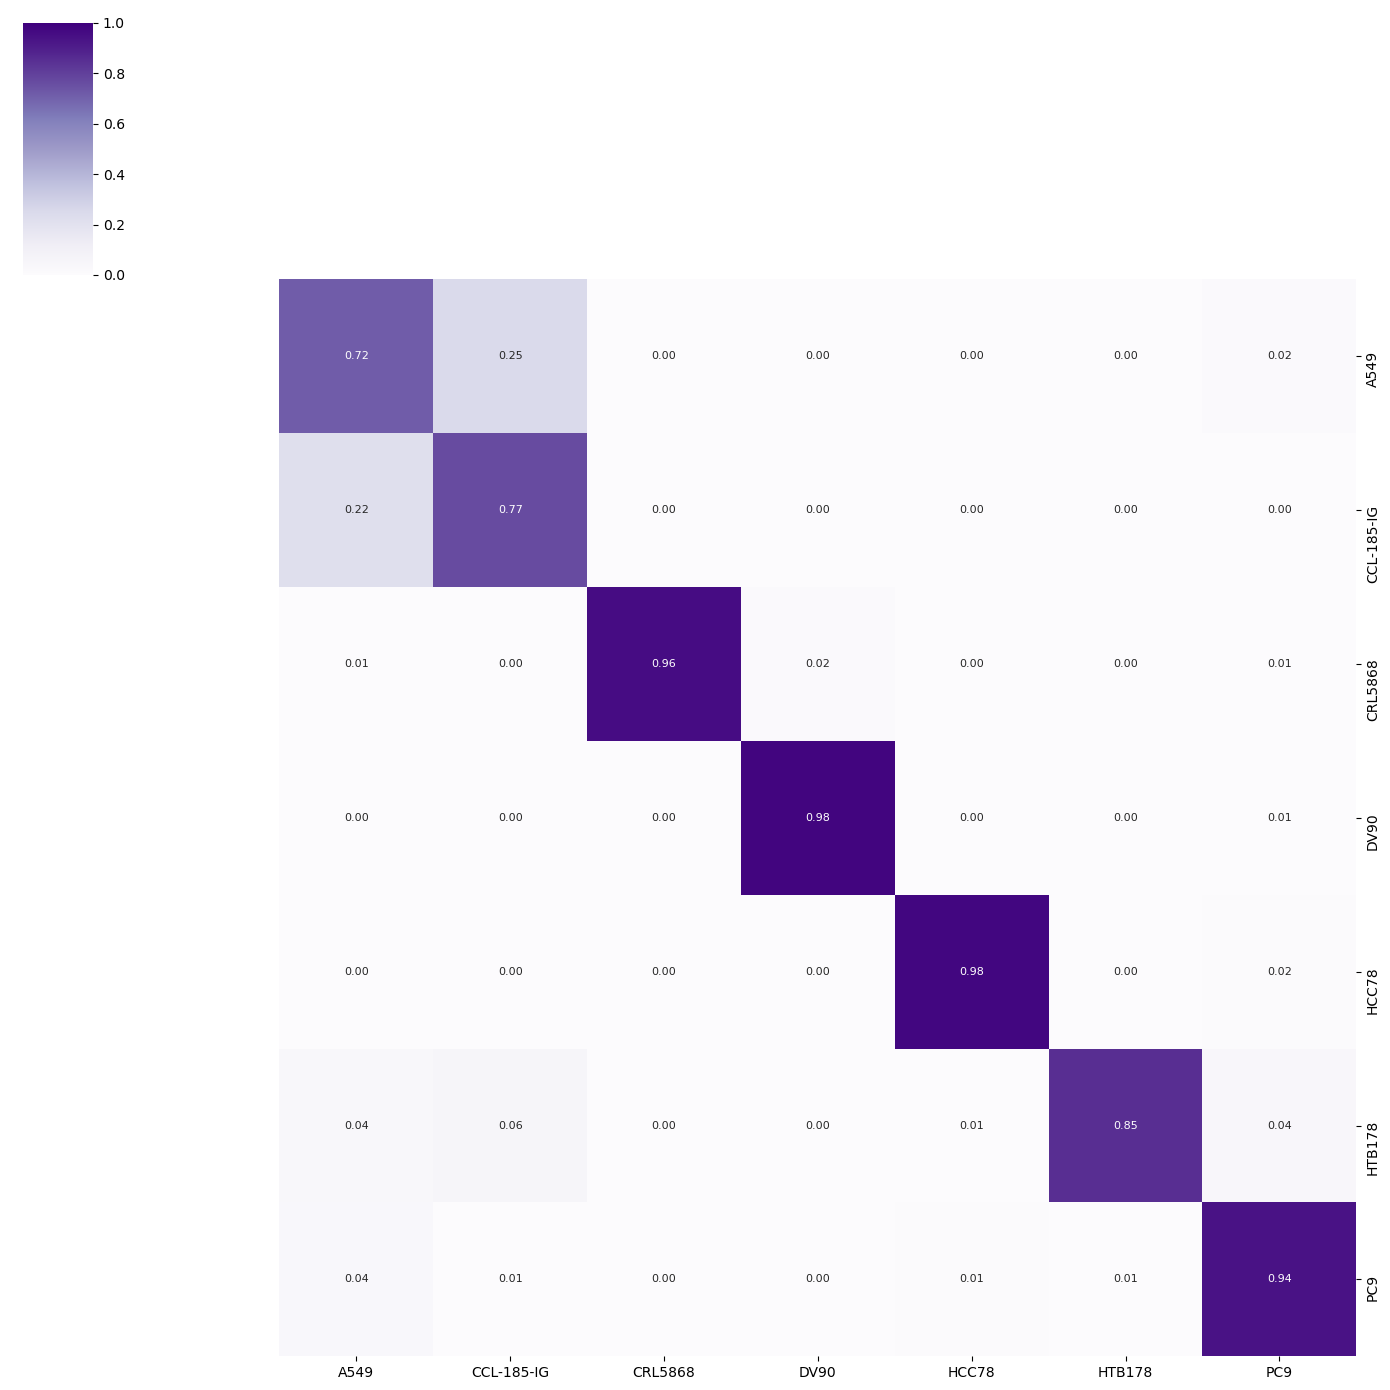

In [13]:
y_true = gt
y_pred = preds
cell_type_list = np.unique(y_true)
matrix = confusion_matrix(y_true, y_pred, labels=cell_type_list)
matrix = matrix.astype("float") / matrix.sum(axis=1)[:, np.newaxis]

df = pd.DataFrame(matrix, index=cell_type_list[:matrix.shape[0]], columns=cell_type_list[:matrix.shape[1]])

ax = sns.clustermap(df,  
                    cmap='Purples',
                    annot=True ,fmt=".2f", 
                    annot_kws={'size': 8}, 
                    vmin=0, 
                    vmax=1,
                    row_cluster=False, 
                    col_cluster=False, 
                    figsize=(14, 14))